In [1]:
# =============================================================================
# BBO Decision Tree Surrogate Analysis Notebook
# Collects BBO history → Trains DT → Scatter plot with R² + perfect prediction line
# =============================================================================

# Cell 1: Imports and Setup
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error
from mealpy.bio_based import BBO as MEALPY_BBO
from mealpy import IntegerVar
import warnings
warnings.filterwarnings('ignore')

print("✅ Imports loaded - Ready for BBO analysis")


✅ Imports loaded - Ready for BBO analysis


In [3]:
# Cell 2: BBO SETUP + RUN (Replace problem_dict with your SAT/GC/BT problem)
# =============================================================================
# SETUP YOUR PROBLEM HERE (example for SAT-like problem)
dimension = 50  # number of variables
lb = tuple([0] * dimension)
ub = tuple([1] * dimension)  # binary SAT problem
bounds = IntegerVar(lb=lb, ub=ub, name="bbo_sat")

# YOUR FITNESS FUNCTION (replace with your benchmark_problem.fitness_function)
def fitness_func(solution):
    """Replace this with your actual fitness function"""
    # Example SAT fitness - replace with your real one
    discrete_solution = np.array(solution, dtype=int)
    # fitness = your_benchmark_problem.fitness_function(FullSolution(discrete_solution))
    fitness = np.sum(discrete_solution) * 0.5 + np.random.random() * 0.1  # DUMMY - REPLACE!
    return float(fitness)

problem_dict = {
    "obj_func": fitness_func,
    "bounds": bounds,
    "minmax": "max",
    "save_population": True
}

# BBO CONFIGURATION (MEALPY defaults)
model = MEALPY_BBO.OriginalBBO(
    epoch=100,
    pop_size=50,
    p_m=0.01,
    n_elites=2
)

print("🚀 Running BBO...")
model.solve(problem_dict, mode='swarm')
print("✅ BBO completed!")


2025/11/29 11:16:24 AM, INFO, mealpy.bio_based.BBO.OriginalBBO: OriginalBBO(epoch=100, pop_size=50, p_m=0.01, n_elites=2)
2025/11/29 11:16:24 AM, INFO, mealpy.bio_based.BBO.OriginalBBO: >>>Problem: P, Epoch: 1, Current best: 16.559357601562784, Global best: 16.559357601562784, Runtime: 0.03108 seconds
2025/11/29 11:16:24 AM, INFO, mealpy.bio_based.BBO.OriginalBBO: >>>Problem: P, Epoch: 2, Current best: 17.002979684058413, Global best: 17.002979684058413, Runtime: 0.04463 seconds
2025/11/29 11:16:24 AM, INFO, mealpy.bio_based.BBO.OriginalBBO: >>>Problem: P, Epoch: 3, Current best: 17.55295086099982, Global best: 17.55295086099982, Runtime: 0.04505 seconds


🚀 Running BBO...


2025/11/29 11:16:24 AM, INFO, mealpy.bio_based.BBO.OriginalBBO: >>>Problem: P, Epoch: 4, Current best: 18.575447823766797, Global best: 18.575447823766797, Runtime: 0.04460 seconds
2025/11/29 11:16:24 AM, INFO, mealpy.bio_based.BBO.OriginalBBO: >>>Problem: P, Epoch: 5, Current best: 20.039668099852026, Global best: 20.039668099852026, Runtime: 0.04974 seconds
2025/11/29 11:16:24 AM, INFO, mealpy.bio_based.BBO.OriginalBBO: >>>Problem: P, Epoch: 6, Current best: 20.52413430932903, Global best: 20.52413430932903, Runtime: 0.04476 seconds
2025/11/29 11:16:24 AM, INFO, mealpy.bio_based.BBO.OriginalBBO: >>>Problem: P, Epoch: 7, Current best: 20.562107219353575, Global best: 20.562107219353575, Runtime: 0.04241 seconds
2025/11/29 11:16:24 AM, INFO, mealpy.bio_based.BBO.OriginalBBO: >>>Problem: P, Epoch: 8, Current best: 21.56990507057645, Global best: 21.56990507057645, Runtime: 0.03796 seconds
2025/11/29 11:16:25 AM, INFO, mealpy.bio_based.BBO.OriginalBBO: >>>Problem: P, Epoch: 9, Current be

✅ BBO completed!


In [5]:
# Cell 3: EXTRACT ALL SOLUTIONS + TRUE FITNESS FROM BBO HISTORY
solutions = []
true_fitness = []

print("📊 Extracting BBO population history...")
for gen_idx, population in enumerate(model.history.list_population):
    for agent in population:
        x = np.array(agent.solution, dtype=int)      # BBO solutions
        f = float(agent.target.fitness)              # True fitness values
        solutions.append(x)
        true_fitness.append(f)

X = np.array(solutions)          # Shape: (N_samples, n_features)
y_true = np.array(true_fitness)  # Shape: (N_samples,)

print(f"✅ Collected {X.shape[0]} datapoints")
print(f"   X shape: {X.shape}")
print(f"   y_true range: [{y_true.min():.3f}, {y_true.max():.3f}]")
print(f"   Mean fitness: {y_true.mean():.3f}")


📊 Extracting BBO population history...
✅ Collected 5000 datapoints
   X shape: (5000, 50)
   y_true range: [10.542, 25.100]
   Mean fitness: 24.252


In [7]:
# Cell 4: TRAIN DECISION TREE SURROGATE ON BBO DATA
dt = DecisionTreeRegressor(
    max_depth=5,
    min_samples_leaf=20,
    random_state=42
)

# Train on ALL data (or split train/test if you prefer)
dt.fit(X, y_true)
y_pred = dt.predict(X)

# Calculate metrics
r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print(f"🎯 BBO Decision Tree Surrogate Performance:")
print(f"   R² Score:    {r2:.4f}")
print(f"   RMSE:        {rmse:.4f}")
print(f"   Tree depth:  {dt.tree_.max_depth}")
print(f"   # Leaves:    {dt.tree_.n_leaves}")


🎯 BBO Decision Tree Surrogate Performance:
   R² Score:    0.9094
   RMSE:        0.7165
   Tree depth:  5
   # Leaves:    17


In [9]:
# Cell 5: SAVE DATA FOR LATER (arrays ready for analysis)
np.save("bbo_y_true.npy", y_true)
np.save("bbo_y_pred.npy", y_pred)
np.save("bbo_X.npy", X)
print("💾 Data saved: bbo_y_true.npy, bbo_y_pred.npy, bbo_X.npy")


💾 Data saved: bbo_y_true.npy, bbo_y_pred.npy, bbo_X.npy


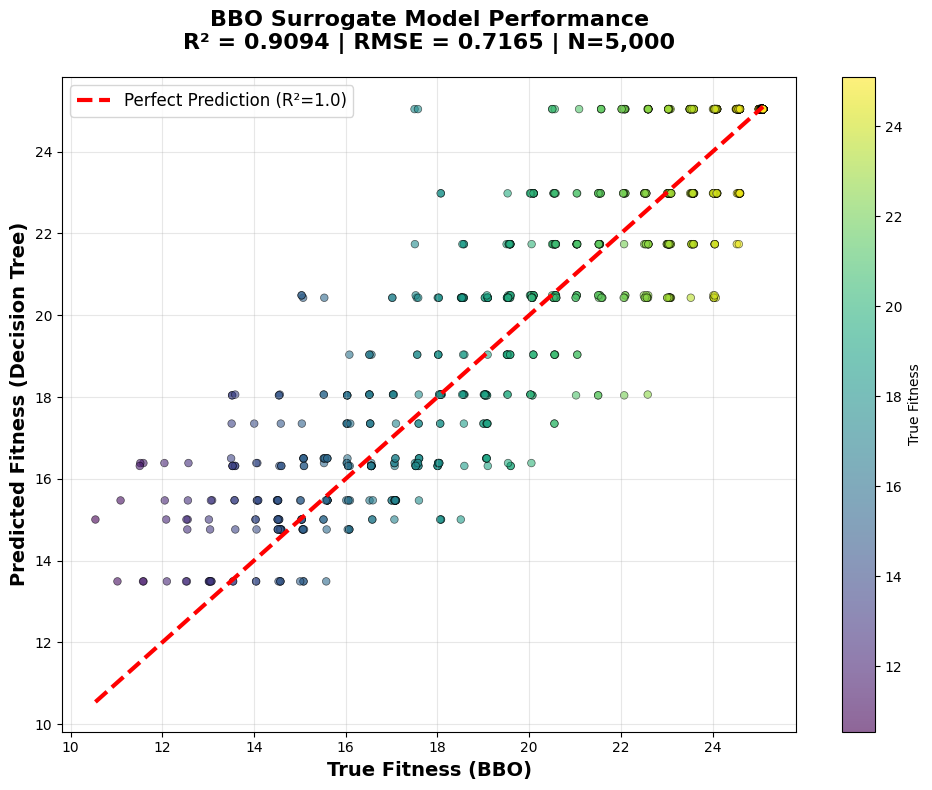

📈 Plot saved: bbo_true_vs_predicted.[png|pdf]


In [11]:
# Cell 6: SCATTER PLOT - True vs Predicted Fitness (BBO)
plt.figure(figsize=(10, 8))

# Scatter plot
scatter = plt.scatter(y_true, y_pred, 
                     alpha=0.6, s=30, c=y_true, cmap='viridis', 
                     edgecolor='k', linewidth=0.5)
plt.colorbar(scatter, label='True Fitness')

# Perfect prediction line (y=x diagonal)
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 
         'r--', linewidth=3, label='Perfect Prediction (R²=1.0)')

# Formatting
plt.xlabel('True Fitness (BBO)', fontsize=14, fontweight='bold')
plt.ylabel('Predicted Fitness (Decision Tree)', fontsize=14, fontweight='bold')
plt.title(f'BBO Surrogate Model Performance\nR² = {r2:.4f} | RMSE = {rmse:.4f} | N={len(y_true):,}', 
          fontsize=16, fontweight='bold', pad=20)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()

# Save for paper
plt.savefig('bbo_true_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.savefig('bbo_true_vs_predicted.pdf', bbox_inches='tight')
plt.show()

print("📈 Plot saved: bbo_true_vs_predicted.[png|pdf]")


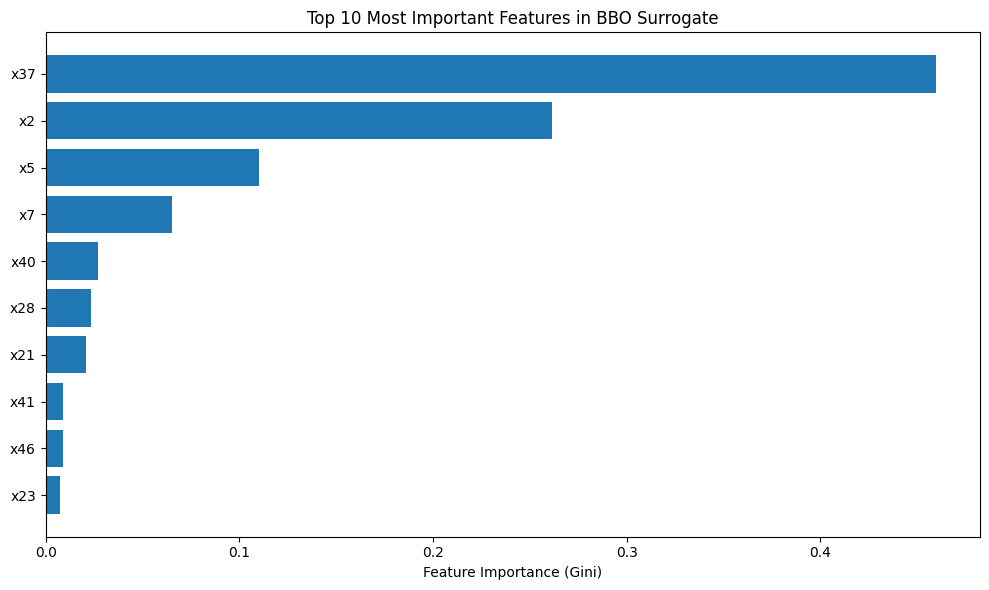

In [13]:
# Cell 7: FEATURE IMPORTANCE (Bonus for your paper)
importances = dt.feature_importances_
top_features = np.argsort(importances)[-10:]  # Top 10 most important

plt.figure(figsize=(10, 6))
plt.barh(range(len(top_features)), importances[top_features])
plt.yticks(range(len(top_features)), [f'x{i}' for i in top_features])
plt.xlabel('Feature Importance (Gini)')
plt.title('Top 10 Most Important Features in BBO Surrogate')
plt.tight_layout()
plt.savefig('bbo_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
